<a href="https://colab.research.google.com/github/Anoushehm/intro-ml-course-winter2026/blob/main/HAD5016_Project_NLP_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Load all papers from a folder

In [3]:
import os

# CHANGE this to your folder path
folder_path = '/content/drive/MyDrive/HAD5016-Project/NLP_papers/'

files = os.listdir(folder_path)
files

['CNS Neuroscience   Therapeutics - 2018 - Gao - Machine learning in major depression  From classification to treatment.pdf',
 '1-s2.0-S1877050920309091-main.pdf',
 '1-s2.0-S2665917422002215-main.pdf',
 '1-s2.0-S2666518221000310-main.pdf',
 'Vaishnavi_2022_J._Phys.__Conf._Ser._2161_012021.pdf',
 'Development_and_validation_of_a_machine.pdf',
 's12911-023-02341-x.pdf',
 'formative-2022-8-e32736.pdf',
 'div-class-title-machine-learning-in-the-prediction-of-depression-treatment-outcomes-a-systematic-review-and-meta-analysis-div.pdf',
 'pi-2022-0075.pdf',
 's10916-018-0934-5.pdf',
 's12530-017-9205-9.pdf',
 'Int J Geriat Psychiatry - 2015 - Patel - Machine learning approaches for integrating clinical and imaging features in.pdf',
 's40708-023-00188-6.pdf',
 'mp2015198.pdf',
 'Applied Computational Intelligence and Soft Computing - 2022 - Chung - Mental Health Prediction Using Machine Learning .pdf',
 's11042-023-16221-z.pdf',
 '1-s2.0-S0165032718304853-mainext.pdf',
 'fpsyt-11-00472.pdf',


# 3. Extract text (PDFs)

In [6]:
!pip install PyPDF2
import PyPDF2

def extract_text_from_pdf(file_path):
    text = ""
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            text += page.extract_text() + " "
    return text

documents = []

for file in files:
    if file.endswith('.pdf'):
        text = extract_text_from_pdf(os.path.join(folder_path, file))
        documents.append(text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 16.7 MB/s eta 0:00:00


# 4. NLP Preprocessing

4.1. Lowercase + cleaning (from lecture)

In [7]:
import re

def clean_text(text):
    text = text.lower()  # lowercasing :contentReference[oaicite:1]{index=1}
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs :contentReference[oaicite:2]{index=2}
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove special characters :contentReference[oaicite:3]{index=3}
    return text

4.2. Stopword removal

In [16]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words.add('al') # Add 'al' to stopwords as 'et al' is commonly split
stop_words.add('et') # Add 'et' to stopwords

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


4.3. Lemmatization

In [11]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Added to explicitly download the English tagger
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in text.split()])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


# 5. Apply preprocessing pipeline

In [17]:
processed_docs = []

for doc in documents:
    text = clean_text(doc)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    processed_docs.append(text)

# Save to CSV

In [18]:
import pandas as pd

df = pd.DataFrame({
    'document_id': range(len(processed_docs)),
    'text': processed_docs
})

df.to_csv('/content/processed_papers.csv', index=False)

# 7. Generate Word Cloud

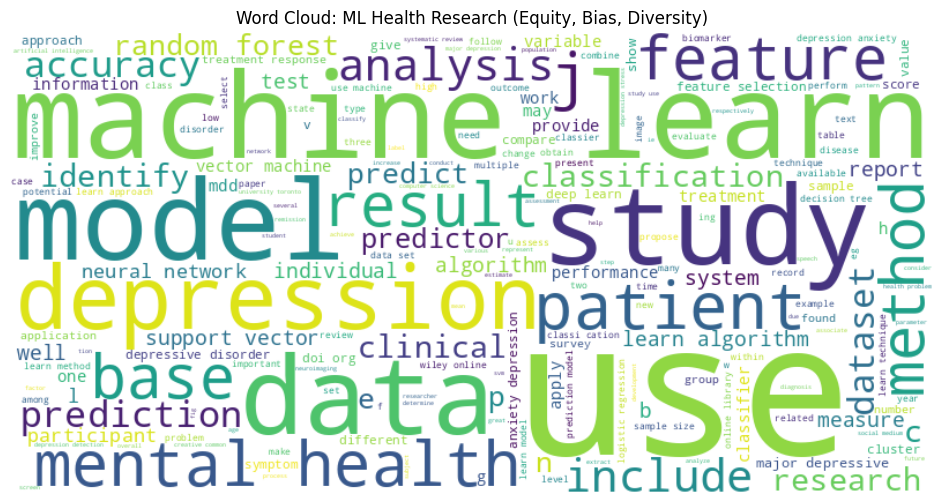

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(processed_docs)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: ML Health Research (Equity, Bias, Diversity)")
plt.show()

# 8. Top words frequency

In [20]:
from collections import Counter

words = all_text.split()
word_freq = Counter(words)

pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

,Word,Frequency
0,depression,1555
1,use,1421
2,model,1237
3,data,1158
4,learn,1030
5,study,961
6,machine,896
7,j,627
8,feature,605
9,health,580
